Recap:

1. train_clean / test_clean are complete: no missing values, row counts preserved.
2. is_holiday covers 5.1% of rows, post_earthquake covers 1.84% of rows.
3. The oil/sales correlation on raw levels (-0.627) mostly disappears on first differences (0.025): oil price is a slow macro trend feature, not a same-day driver.
4. test.csv covers exactly 16 days, starting the day right after the last training date. This is the forecast horizon, and it directly constrains how we can build lag features below.

*Also driving this revision:* notebook 04's real feature importance showed the model leaning almost entirely on lags and rolling means for cyclical information, with only the coarse month category for seasonality and nothing at all for the multi-year trend confirmed in notebook 01. This revision adds an explicit trend index and Fourier seasonality terms to address that gap directly.


*Goal:* turn train_clean / test_clean into a modeling-ready feature table. Concretely:

1. Setup and loading (this notebook consumes notebook 02's output as its input dataset)
2. Target transform (log1p(sales))
3. Calendar features (day of week, month, payday distance)
4. Trend and Fourier seasonality features
5. Categorical features (family, store type, cluster, city, state)
6. Holiday sensitivity by family (with a leakage caveat for later notebooks)
7. Lag and rolling mean features, respecting the 16 day forecast horizon
8. Assembling and checking the final feature tables
9. Exporting train_features.csv / test_features.csv

Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
train_clean = pd.read_csv("train_clean.csv")
test_clean = pd.read_csv("test_clean.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

In [5]:
train_clean["date"] = pd.to_datetime(train_clean["date"])
test_clean["date"] = pd.to_datetime(test_clean["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
transactions["date"] = pd.to_datetime(transactions["date"])

In [6]:
forecast_horizon = (test_clean['date'].min() - train_clean['date'].max()).days
print(f"Test set starts {forecast_horizon} day(s) after the last training date")
print(f"Test date range: {test_clean['date'].min().date()} to {test_clean['date'].max().date()} "
      f"({test_clean['date'].nunique()} days)")

FORECAST_HORIZON = test_clean['date'].nunique()
print(f"FORECAST_HORIZON set to {FORECAST_HORIZON} days")

Test set starts 1 day(s) after the last training date
Test date range: 2017-08-16 to 2017-08-31 (16 days)
FORECAST_HORIZON set to 16 days


This confirms the forecast horizon is 16 days. Every lag or rolling feature we build below must look back at least 16 days, otherwise it would rely on data that simply will not exist when we need to predict the test period.

*Target transform:*
As found in notebook 1, sales is strongly skewed with many zeros, and the competition metric (RMSLE) operates on log(1 + sales). We create sales_log and will model on it.

In [7]:
train_clean['sales_log'] = np.log1p(train_clean['sales'])

print(train_clean[['sales', 'sales_log']].describe())

              sales     sales_log
count  3.000888e+06  3.000888e+06
mean   3.577757e+02  2.926368e+00
std    1.101998e+03  2.695122e+00
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    1.100000e+01  2.484907e+00
75%    1.958473e+02  5.282428e+00
max    1.247170e+05  1.173381e+01


*Calendar features:*
Simple, well understood features derived from date. is_payday reuses the definition validated in notebook 1 (15th of the month or month end).

In [8]:
def add_calendar_features(df):
    df = df.copy()
    df['day_of_week'] = df['date'].dt.dayofweek  # 0 = Monday
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['is_weekend'] = df['day_of_week'].isin([5, 6])
    df['is_month_end'] = df['date'].dt.is_month_end
    df['is_payday'] = (df['day_of_month'] == 15) | df['is_month_end']
    return df


train_clean = add_calendar_features(train_clean)
test_clean = add_calendar_features(test_clean)

train_clean[['date', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'is_payday']].head()

,date,day_of_week,day_of_month,month,year,is_weekend,is_payday
0,2013-01-01,1,1,1,2013,False,False
1,2013-01-01,1,1,1,2013,False,False
2,2013-01-01,1,1,1,2013,False,False
3,2013-01-01,1,1,1,2013,False,False
4,2013-01-01,1,1,1,2013,False,False


Trend and seasonality features (Fourier)¶
Notebook 04's feature importance showed the model relying almost entirely on lags and rolling means for cyclical information, with the coarse month category as the only explicit seasonal signal, and nothing at all capturing the multi-year upward trend confirmed in notebook 01. We add two complementary pieces here:

1. trend: a simple linear day index since the first date in the series. It gives the model a within-sample notion of "era" (early years tend to differ systematically from later years). It is worth being upfront about a real limitation: LightGBM, like any tree-based model, splits into piecewise-constant leaves. Every test-period date falls beyond the maximum trend value ever seen in training, so the model cannot use this raw feature to linearly project the growth trend forward the way a regression would, it can only fall back to whatever prediction its highest-trend leaf learned. Closing that gap properly is exactly what the hybrid model planned for the next phase (a trend/seasonality regression combined with LightGBM on the residuals) is for. We still add it here since it helps the model use lags and other features differently across eras, and because it is a building block the future hybrid model will reuse.

2. Fourier terms for the annual cycle (sin_year_1..4, cos_year_1..4, based on day-of-year): unlike trend, these are bounded in [-1, 1] and purely cyclical, so a test-period date has a Fourier feature value directly comparable to historical dates at the same point in the yearly cycle, regardless of which year they fall in. This gives the model a precise, continuous handle on the annual seasonality (the December peak, the summer patterns) instead of the blunt 12-bucket month category, with no extrapolation problem.

In [9]:
GLOBAL_START = train_clean['date'].min()
FOURIER_ORDER = 4


def add_trend_seasonality_features(df):
    df = df.copy()
    df['trend'] = (df['date'] - GLOBAL_START).dt.days

    day_of_year = df['date'].dt.dayofyear
    for k in range(1, FOURIER_ORDER + 1):
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * day_of_year / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * day_of_year / 365.25)
    return df


train_clean = add_trend_seasonality_features(train_clean)
test_clean = add_trend_seasonality_features(test_clean)

fourier_cols = [c for c in train_clean.columns if c.startswith('sin_year_') or c.startswith('cos_year_')]
print(f"trend range in train: {train_clean['trend'].min()} to {train_clean['trend'].max()}")
print(f"trend range in test : {test_clean['trend'].min()} to {test_clean['trend'].max()} "
      f"(entirely beyond the training range, as expected)")
train_clean[['date', 'trend'] + fourier_cols].head()

trend range in train: 0 to 1687
trend range in test : 1688 to 1703 (entirely beyond the training range, as expected)


,date,trend,sin_year_1,cos_year_1,sin_year_2,cos_year_2,sin_year_3,cos_year_3,sin_year_4,cos_year_4
0,2013-01-01,0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634
1,2013-01-01,0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634
2,2013-01-01,0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634
3,2013-01-01,0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634
4,2013-01-01,0,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634


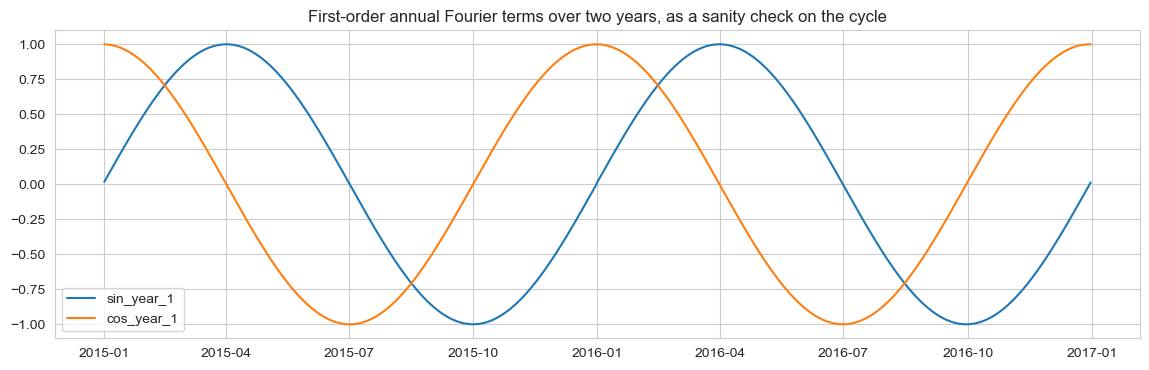

In [10]:
sample_year = train_clean[(train_clean['date'] >= '2015-01-01') & (train_clean['date'] < '2017-01-01')]
sample_year = sample_year[['date', 'sin_year_1', 'cos_year_1']].drop_duplicates(subset='date')

plt.figure(figsize=(14, 4))
plt.plot(sample_year['date'], sample_year['sin_year_1'], label='sin_year_1')
plt.plot(sample_year['date'], sample_year['cos_year_1'], label='cos_year_1')
plt.title('First-order annual Fourier terms over two years, as a sanity check on the cycle')
plt.legend()
plt.show()

The two-year plot confirms a clean, smooth annual cycle with no discontinuity at the year boundary, exactly the property that makes these features usable on unseen future dates.

*Categorical features:*
family, store_type, city, state and cluster are heterogeneous, as shown in notebook 1 (large differences in average sales across clusters, types and cities). We convert them to the pandas category dtype rather than manual label encoding, so that category aware models (LightGBM, CatBoost) can use them natively, without an arbitrary ordinal assumption between codes.

In [11]:
categorical_cols = ['family', 'store_type', 'city', 'state', 'cluster', 'store_nbr']

for col in categorical_cols:
    train_clean[col] = train_clean[col].astype('category')
    test_clean[col] = test_clean[col].astype('category')

# Keep the same categories on both sides so encodings stay aligned
for col in categorical_cols:
    all_categories = pd.api.types.union_categoricals(
        [train_clean[col], test_clean[col]]
    ).categories
    train_clean[col] = train_clean[col].cat.set_categories(all_categories)
    test_clean[col] = test_clean[col].cat.set_categories(all_categories)

    train_clean[categorical_cols].dtypes

*Holiday sensitivity by family:*
Notebook 2 suggested checking whether the holiday effect differs across product families. We compute it here as a family level statistic on the training data.

Leakage caveat: this is an aggregate computed from the full training set, so a given row's own sales value contributes (in a small way) to its own feature value. This is acceptable for building the final submission (test is a fully disjoint period), but if notebooks 04/05 use cross validation on the training period, this feature must be recomputed out-of-fold (using only the training folds) to avoid an overly optimistic validation score. We flag it clearly here so it is not forgotten later.

In [12]:
family_holiday = (
    train_clean.groupby(['family', 'is_holiday'], observed=True)['sales']
    .mean()
    .unstack()
)
family_holiday['holiday_uplift_pct'] = (
    (family_holiday[True] - family_holiday[False]) / family_holiday[False]
) * 100

family_holiday_sorted = family_holiday.sort_values('holiday_uplift_pct', ascending=False)
print("Top 10 families with the strongest positive holiday effect:")
print(family_holiday_sorted[['holiday_uplift_pct']].head(10))
print()
print("Top 10 families with the strongest negative holiday effect:")
print(family_holiday_sorted[['holiday_uplift_pct']].tail(10))

Top 10 families with the strongest positive holiday effect:
is_holiday               holiday_uplift_pct
family                                     
FROZEN FOODS                     217.536243
LIQUOR,WINE,BEER                 122.798345
BOOKS                             83.450805
LAWN AND GARDEN                   55.752501
PLAYERS AND ELECTRONICS           49.499719
GROCERY II                        49.469721
HOME AND KITCHEN I                48.221063
MAGAZINES                         39.785953
BEAUTY                            28.917409
HOME APPLIANCES                   28.110290

Top 10 families with the strongest negative holiday effect:
is_holiday                  holiday_uplift_pct
family                                        
CLEANING                             13.575297
HARDWARE                             12.871927
LINGERIE                             12.009126
BABY CARE                             9.954457
PREPARED FOODS                        9.523203
EGGS                  

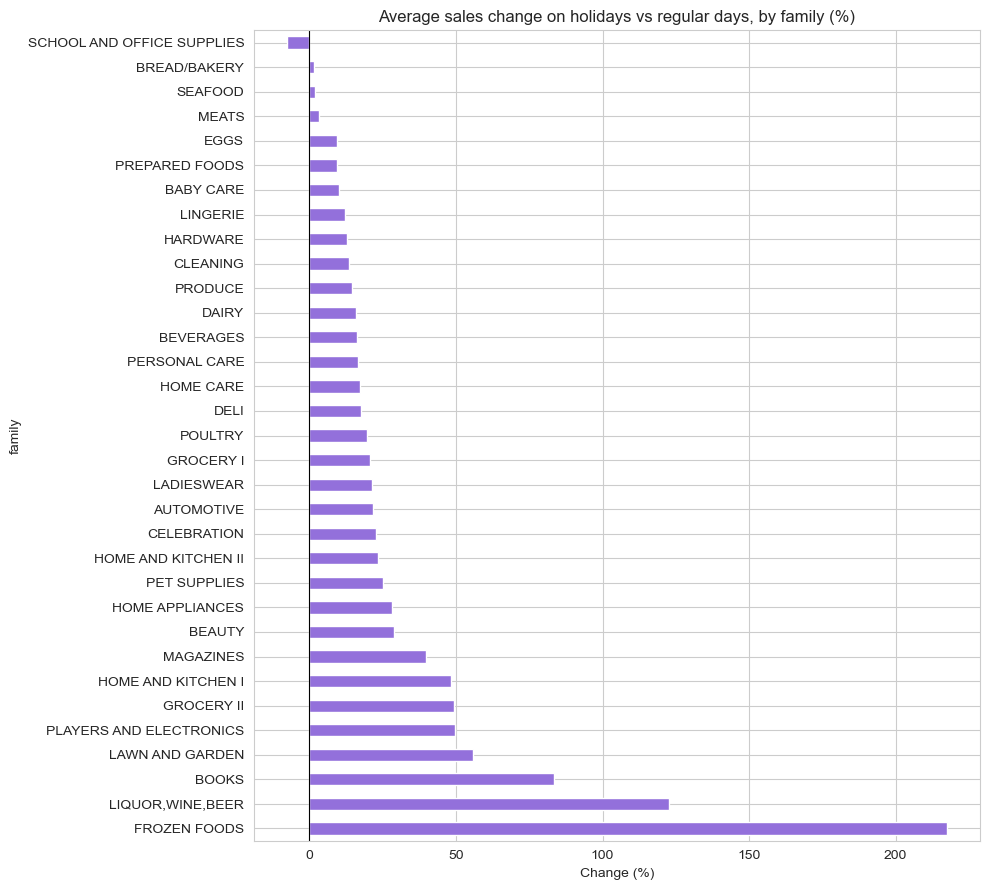

In [13]:
plt.figure(figsize=(10, 9))
family_holiday_sorted['holiday_uplift_pct'].plot(kind='barh', color='mediumpurple')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Average sales change on holidays vs regular days, by family (%)")
plt.xlabel("Change (%)")
plt.tight_layout()
plt.show()

In [14]:
family_uplift_map = family_holiday_sorted['holiday_uplift_pct'].to_dict()

train_clean['family_holiday_sensitivity'] = train_clean['family'].map(family_uplift_map)
test_clean['family_holiday_sensitivity'] = test_clean['family'].map(family_uplift_map)

print("Missing values after mapping:",
      train_clean['family_holiday_sensitivity'].isna().sum(),
      test_clean['family_holiday_sensitivity'].isna().sum())

Missing values after mapping: 0 0


Some families show a clear positive holiday effect and others a negative one, confirming that a single global is_holiday flag was hiding meaningful differences. family_holiday_sensitivity captures this as a numeric feature, with the leakage caveat noted above.

*Lag and rolling mean features:*
This is the part most affected by the 16 day forecast horizon. A lag_1 (yesterday's sales) feature would be perfectly available for training, but completely unavailable for most of the test period, since we do not know sales for the days in between. Every lag and rolling window used here therefore starts at FORECAST_HORIZON (16 days) or more, so the exact same feature computation is valid for both train and test rows.

We concatenate train_clean and test_clean along the time axis first (test rows get a missing sales_log), compute the lag and rolling features on the combined series per store-family pair, then split them back apart. This way, the first days of the test period correctly pull their lag values from the tail of the training period.

In [15]:
LAGS = [16, 21, 28, 35]
ROLLING_WINDOWS = [7, 14, 28]

combined = pd.concat(
    [train_clean[['id', 'date', 'store_nbr', 'family', 'sales_log']],
     test_clean[['id', 'date', 'store_nbr', 'family']].assign(sales_log=np.nan)],
    ignore_index=True
)
combined = combined.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

group = combined.groupby(['store_nbr', 'family'], observed=True)['sales_log']

for lag in LAGS:
    combined[f'lag_{lag}'] = group.shift(lag)

for window in ROLLING_WINDOWS:
    # Rolling mean computed on the series already shifted by the forecast horizon,
    # so it only ever uses data at least 16 days old, available for both train and test.
    combined[f'rolling_mean_{window}_h{FORECAST_HORIZON}'] = (
        combined.groupby(['store_nbr', 'family'], observed=True)['sales_log']
        .transform(lambda s: s.shift(FORECAST_HORIZON).rolling(window).mean())
    )

lag_cols = [c for c in combined.columns if c.startswith('lag_') or c.startswith('rolling_')]
print(f"Lag/rolling columns created: {lag_cols}")
combined[['date', 'store_nbr', 'family'] + lag_cols].tail(3)

Lag/rolling columns created: ['lag_16', 'lag_21', 'lag_28', 'lag_35', 'rolling_mean_7_h16', 'rolling_mean_14_h16', 'rolling_mean_28_h16']


,date,store_nbr,family,lag_16,lag_21,lag_28,lag_35,rolling_mean_7_h16,rolling_mean_14_h16,rolling_mean_28_h16
3029397,2017-08-29,54,SEAFOOD,1.098612,2.564949,1.386294,2.079442,1.009251,1.044631,1.164543
3029398,2017-08-30,54,SEAFOOD,0.000000,1.609438,1.386294,1.386294,1.009251,0.929672,1.115032
3029399,2017-08-31,54,SEAFOOD,1.386294,1.098612,1.791759,1.098612,0.840872,0.929672,1.095046


In [16]:
train_lags = combined.loc[combined['id'].isin(train_clean['id']), ['id'] + lag_cols]
test_lags = combined.loc[combined['id'].isin(test_clean['id']), ['id'] + lag_cols]

train_clean = train_clean.merge(train_lags, on='id', how='left')
test_clean = test_clean.merge(test_lags, on='id', how='left')

print(f"train_clean: {train_clean.shape}")
print(f"test_clean : {test_clean.shape}")
print()
print("Missing values in the lag/rolling columns, test set (should be 0, full train history is always behind it):")
print(test_clean[lag_cols].isna().sum())

train_clean: (3000888, 38)
test_clean : (28512, 36)

Missing values in the lag/rolling columns, test set (should be 0, full train history is always behind it):
lag_16                 0
lag_21                 0
lag_28                 0
lag_35                 0
rolling_mean_7_h16     0
rolling_mean_14_h16    0
rolling_mean_28_h16    0
dtype: int64


In [17]:
print("Missing values in the lag/rolling columns, train set (expected for the first days of each series, not enough history yet):")
print(train_clean[lag_cols].isna().sum())
print()
rows_with_full_history = train_clean[lag_cols].notna().all(axis=1).sum()
print(f"Training rows with a complete lag history: {rows_with_full_history:,} / {len(train_clean):,} "
      f"({rows_with_full_history / len(train_clean):.1%})")

Missing values in the lag/rolling columns, train set (expected for the first days of each series, not enough history yet):
lag_16                 28512
lag_21                 37422
lag_28                 49896
lag_35                 62370
rolling_mean_7_h16     39204
rolling_mean_14_h16    51678
rolling_mean_28_h16    76626
dtype: int64

Training rows with a complete lag history: 2,924,262 / 3,000,888 (97.4%)


Test rows never have missing lag values, as expected: the 16 day horizon means every lag and rolling feature for the test period is anchored inside the training period, which is always fully populated. Training rows are missing lag values only for the first lag + rolling_window days of each store-family series, since there is simply not enough history yet. Those early rows should be excluded when training a model that uses these features (notebook 04/05 will drop or otherwise handle them), but they remain valid for models that do not rely on lag features.

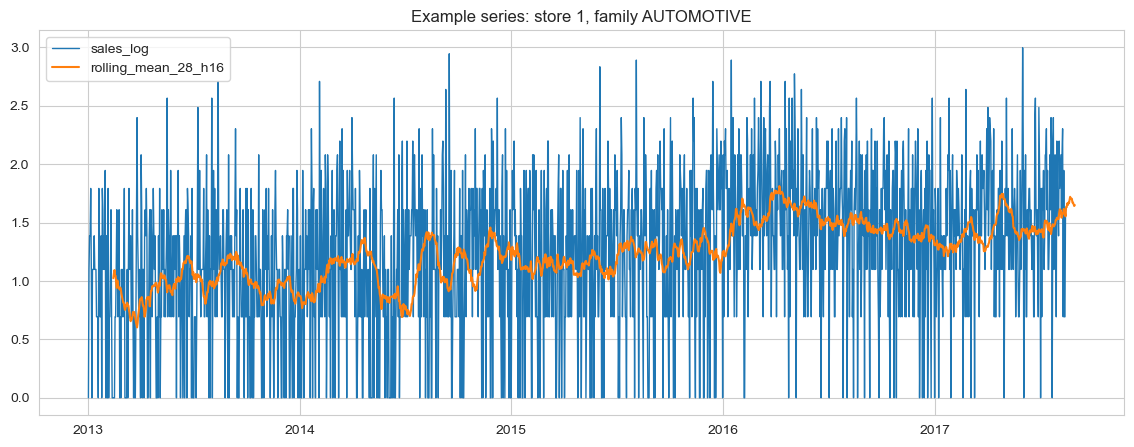

In [18]:
plt.figure(figsize=(14, 5))
sample_series = combined[(combined['store_nbr'] == combined['store_nbr'].iloc[0]) &
                          (combined['family'] == combined['family'].iloc[0])]
plt.plot(sample_series['date'], sample_series['sales_log'], label='sales_log', linewidth=1)
plt.plot(sample_series['date'], sample_series[f'rolling_mean_28_h{FORECAST_HORIZON}'],
          label=f'rolling_mean_28_h{FORECAST_HORIZON}', linewidth=1.5)
plt.title(f"Example series: store {sample_series['store_nbr'].iloc[0]}, "
          f"family {sample_series['family'].iloc[0]}")
plt.legend()
plt.show()


Assembling and checking the final feature tables

In [19]:
feature_cols = (
    ['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'onpromotion',
     'oil_price', 'is_holiday', 'post_earthquake', 'family_holiday_sensitivity',
     'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'is_payday']
    + fourier_cols
    + lag_cols
)

train_features = train_clean[['id', 'date', 'sales', 'sales_log'] + feature_cols].copy()
test_features = test_clean[['id', 'date'] + feature_cols].copy()

print(f"train_features: {train_features.shape}")
print(f"test_features : {test_features.shape}")
print()
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

train_features: (3000888, 36)
test_features : (28512, 34)

Feature columns (32): ['store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'onpromotion', 'oil_price', 'is_holiday', 'post_earthquake', 'family_holiday_sensitivity', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'is_payday', 'sin_year_1', 'cos_year_1', 'sin_year_2', 'cos_year_2', 'sin_year_3', 'cos_year_3', 'sin_year_4', 'cos_year_4', 'lag_16', 'lag_21', 'lag_28', 'lag_35', 'rolling_mean_7_h16', 'rolling_mean_14_h16', 'rolling_mean_28_h16']


In [20]:
assert len(train_features) == len(train_clean)
assert len(test_features) == len(test_clean)
assert test_features[lag_cols].isna().sum().sum() == 0, "Test set should never have missing lag features"

print("Row counts preserved: OK")
print("No missing lag features in the test set: OK")

Row counts preserved: OK
No missing lag features in the test set: OK


*Exporting the feature tables:*
As with notebook 02 Cleaning and Preprocessing, we export the results so notebook 04 can pick up from here directly, by attaching this notebook's output as an input dataset.

In [ ]:
train_features.to_csv('train_features.csv', index=False)
test_features.to_csv('test_features.csv', index=False)

print("Files written: train_features.csv, test_features.csv")

Summary and handoff to next notebook

*What was added on top of train_clean / test_clean:*
1. sales_log: the modeling target, log1p(sales).
2. Calendar features: day_of_week, day_of_month, month, year, is_weekend, is_payday.
3. trend: a linear day index since the first date in the series (limited extrapolation value for a pure tree model, see the caveat in section 4, but a useful building block for a future hybrid model).
4. Fourier annual seasonality terms: sin_year_1..4, cos_year_1..4, bounded and cyclical, usable identically on any future date regardless of year.
5. Categorical features converted to pandas category dtype with aligned categories between train and test: family, store_type, city, state, cluster, store_nbr.
6. family_holiday_sensitivity: average holiday sales uplift per family (flagged for out-of-fold recomputation if used in cross validation).
7. Lag features (lag_16, lag_21, lag_28, lag_35) and rolling means (rolling_mean_7_h16, rolling_mean_14_h16, rolling_mean_28_h16) on sales_log, all anchored at least 16 days back so they are available identically for train and test.

In [ ]:
*Summary and handoff to next notebook
What was added on top of train_clean / test_clean
sales_log: the modeling target, log1p(sales).
Calendar features: day_of_week, day_of_month, month, year, is_weekend, is_payday.
trend: a linear day index since the first date in the series (limited extrapolation value for a pure tree model, see the caveat in section 4, but a useful building block for a future hybrid model).
Fourier annual seasonality terms: sin_year_1..4, cos_year_1..4, bounded and cyclical, usable identically on any future date regardless of year.
Categorical features converted to pandas category dtype with aligned categories between train and test: family, store_type, city, state, cluster, store_nbr.
family_holiday_sensitivity: average holiday sales uplift per family (flagged for out-of-fold recomputation if used in cross validation).
Lag features (lag_16, lag_21, lag_28, lag_35) and rolling means (rolling_mean_7_h16, rolling_mean_14_h16, rolling_mean_28_h16) on sales_log, all anchored at least 16 days back so they are available identically for train and test.
Important constraint to remember for nexts notebooks
The 16 day forecast horizon means no feature can use information from less than 16 days back. Any new engineered feature must respect this or it will not be usable at prediction time.
Training rows from the first weeks of each store-family series have missing lag values (not enough history yet) and should be filtered out, or handled explicitly, before fitting a model that uses these features.
family_holiday_sensitivity needs an out-of-fold recomputation if used inside a cross validation loop.
trend cannot help a tree-based model extrapolate the growth trend into the test period on its own, since every test-period value falls beyond the training range. A regression-based hybrid model is the proper way to capture that part of the signal.